<a href="https://colab.research.google.com/github/matteuscruz/irc_vendaval/blob/main/IRB_LSTM_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First, we need to import the `pandas` library to handle data loading and manipulation. Then, we'll load the data from the specified path into a DataFrame and display its first 5 rows to get a quick overview.

In [1]:
import pandas as pd
import xarray as xr

# Define the path to your dataset
data_path = '/content/drive/MyDrive/- IRB/Vendaval-IA/dataset/raw'

# Attempt to read a data file from the path. If your file is a different type, please let me know.
# To list files in the directory and then choose one:
import os
files_in_dir = os.listdir(data_path)
print(f"Files found in '{data_path}': {files_in_dir}")

# Let's try to load the first NetCDF (.nc) file we find, as detected previously.
nc_files = [f for f in files_in_dir if f.endswith('.nc')]
if nc_files:
    first_nc_file = nc_files[0]
    full_file_path = os.path.join(data_path, first_nc_file)
    print(f"Attempting to load NetCDF file: {full_file_path}")
    try:
        ds = xr.open_dataset(full_file_path)
        print("NetCDF data loaded successfully!")
        display(ds) # Display the xarray Dataset
    except Exception as e:
        print(f"Error loading NetCDF file: {e}")
        print("Please ensure the file is a valid NetCDF or specify the correct file type and name.")
elif [f for f in files_in_dir if f.endswith('.csv')]:
    # Fallback to CSV loading if .nc files are not found but .csv files exist (though this was handled earlier)
    csv_files = [f for f in files_in_dir if f.endswith('.csv')]
    first_csv_file = csv_files[0]
    full_file_path = os.path.join(data_path, first_csv_file)
    print(f"Attempting to load CSV file: {full_file_path}")
    try:
        df = pd.read_csv(full_file_path)
        print("CSV data loaded successfully!")
        display(df.head())
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        print("Please ensure the file is a valid CSV or specify the correct file type and name.")
else:
    print("No recognizable data files (.nc or .csv) found in the specified directory. Please specify the exact file name and type.")


Files found in '/content/drive/MyDrive/- IRB/Vendaval-IA/dataset/raw': ['INMET_Stratified.nc', 'ERA5_Stratified.nc']
Attempting to load NetCDF file: /content/drive/MyDrive/- IRB/Vendaval-IA/dataset/raw/INMET_Stratified.nc
NetCDF data loaded successfully!


<xarray.Dataset> Size: 1MB
Dimensions:                           (time: 1827, estacao: 30)
Coordinates:
  * time                              (time) datetime64[ns] 15kB 2020-01-01 ....
  * estacao                           (estacao) <U4 480B 'A894' ... 'A802'
    latitude                          (estacao) float64 240B ...
    longitude                         (estacao) float64 240B ...
Data variables:
    daily_wind_gust_max               (time, estacao) float64 438kB ...
    daily_wind_speed_mean             (time, estacao) float64 438kB ...
    daily_wind_direction_at_gust_max  (time, estacao) float64 438kB ...

### Carregando ambos os conjuntos de dados (INMET e ERA5)

Para realizar uma análise agregada, precisamos carregar os dois arquivos NetCDF identificados anteriormente no diretório.

In [2]:
import xarray as xr
import os

# Caminhos completos para os arquivos
inmet_path = os.path.join(data_path, 'INMET_Stratified.nc')
era5_path = os.path.join(data_path, 'ERA5_Stratified.nc')

# Carregando os datasets
ds_inmet = xr.open_dataset(inmet_path)
ds_era5 = xr.open_dataset(era5_path)

print("Dataset INMET carregado:")
display(ds_inmet)

print("\nDataset ERA5 carregado:")
display(ds_era5)

Dataset INMET carregado:


<xarray.Dataset> Size: 1MB
Dimensions:                           (time: 1827, estacao: 30)
Coordinates:
  * time                              (time) datetime64[ns] 15kB 2020-01-01 ....
  * estacao                           (estacao) <U4 480B 'A894' ... 'A802'
    latitude                          (estacao) float64 240B ...
    longitude                         (estacao) float64 240B ...
Data variables:
    daily_wind_gust_max               (time, estacao) float64 438kB ...
    daily_wind_speed_mean             (time, estacao) float64 438kB ...
    daily_wind_direction_at_gust_max  (time, estacao) float64 438kB ...


Dataset ERA5 carregado:


<xarray.Dataset> Size: 388MB
Dimensions:                  (time: 229991, estacao: 30)
Coordinates:
  * time                     (time) datetime64[ns] 2MB 2000-01-01 ... 2026-03...
  * estacao                  (estacao) <U4 480B 'A894' 'A809' ... 'A812' 'A802'
    latitude                 (estacao) float64 240B ...
    longitude                (estacao) float64 240B ...
Data variables:
    10m_u_component_of_wind  (time, estacao) float64 55MB ...
    10m_v_component_of_wind  (time, estacao) float64 55MB ...
    2m_dewpoint_temperature  (time, estacao) float64 55MB ...
    2m_temperature           (time, estacao) float64 55MB ...
    mean_sea_level_pressure  (time, estacao) float64 55MB ...
    surface_pressure         (time, estacao) float64 55MB ...
    total_precipitation      (time, estacao) float64 55MB ...

### Agregação Espaço-Temporal

Agora vamos calcular a média da velocidade do vento (`daily_wind_speed_mean`) para ambos os datasets, agregando por tempo (média diária geral) e por estação/localização.

In [3]:
import numpy as np

# Para o INMET, usamos a variável existente
inmet_wind = ds_inmet['daily_wind_speed_mean']

# Para o ERA5, calculamos a magnitude da velocidade a partir dos componentes u e v
era5_wind = np.sqrt(ds_era5['10m_u_component_of_wind']**2 + ds_era5['10m_v_component_of_wind']**2)
era5_wind.name = 'wind_speed'

# Média temporal (média de todas as estações por dia)
inmet_time_series = inmet_wind.mean(dim='estacao')
era5_time_series = era5_wind.mean(dim='estacao')

# Média espacial (média de todo o período por estação)
inmet_spatial = inmet_wind.mean(dim='time')
era5_spatial = era5_wind.mean(dim='time')

print("Médias calculadas com sucesso para ambos os datasets (ERA5 calculado via componentes u/v).")

Médias calculadas com sucesso para ambos os datasets (ERA5 calculado via componentes u/v).


To visualize the data spatially, let's plot the average wind speed at each station. We'll use the `latitude` and `longitude` coordinates available in the dataset for each station and color-code the points based on their average wind speed over the entire period.

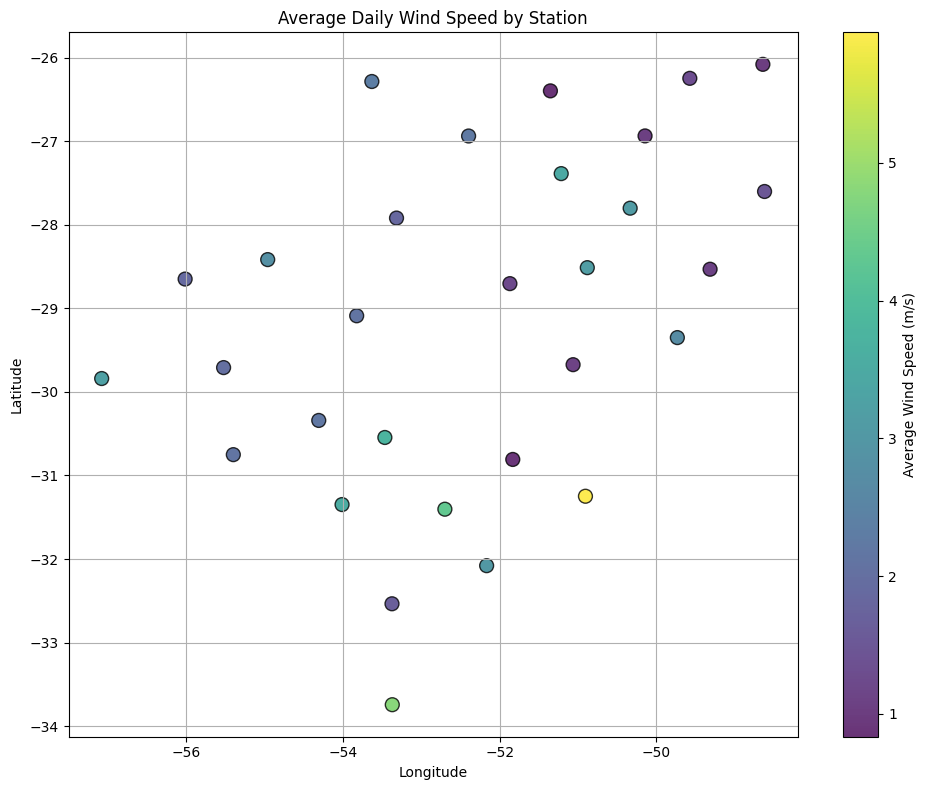

In [4]:
import matplotlib.pyplot as plt

# Calculate the mean of 'daily_wind_speed_mean' for each station over the entire time period
average_wind_speed_per_station = ds['daily_wind_speed_mean'].mean(dim='time')

# Get the latitude and longitude for each station
# These coordinates are constant for each station, so we access them directly.
station_latitudes = ds['latitude']
station_longitudes = ds['longitude']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    station_longitudes.values,
    station_latitudes.values,
    c=average_wind_speed_per_station.values,
    cmap='viridis', # Colormap for wind speed
    s=100,          # Size of points
    edgecolors='black', # Black border for points
    alpha=0.8       # Transparency
)

plt.colorbar(scatter, label='Average Wind Speed (m/s)')
plt.title('Average Daily Wind Speed by Station')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()


To add the state boundaries of Brazil, we'll use the `geopandas` library. We'll install it first, then load a GeoJSON file with the state shapes, and finally overlay these shapes on our existing plot.

In [5]:
# Install geopandas. This may take a moment.
!pip install geopandas matplotlib-scalebar

# Import necessary libraries
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

In [6]:
# Load Brazilian state boundaries from a GeoJSON file
# This is a public GeoJSON for Brazilian states, often used for visualization.
brazil_states_gdf = gpd.read_file("https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson")

print("Brazilian state boundaries loaded successfully!")


Brazilian state boundaries loaded successfully!


Now, let's modify the previous cell to incorporate these state boundaries into the spatial plot. We'll plot the state boundaries first, and then overlay our station data on top.

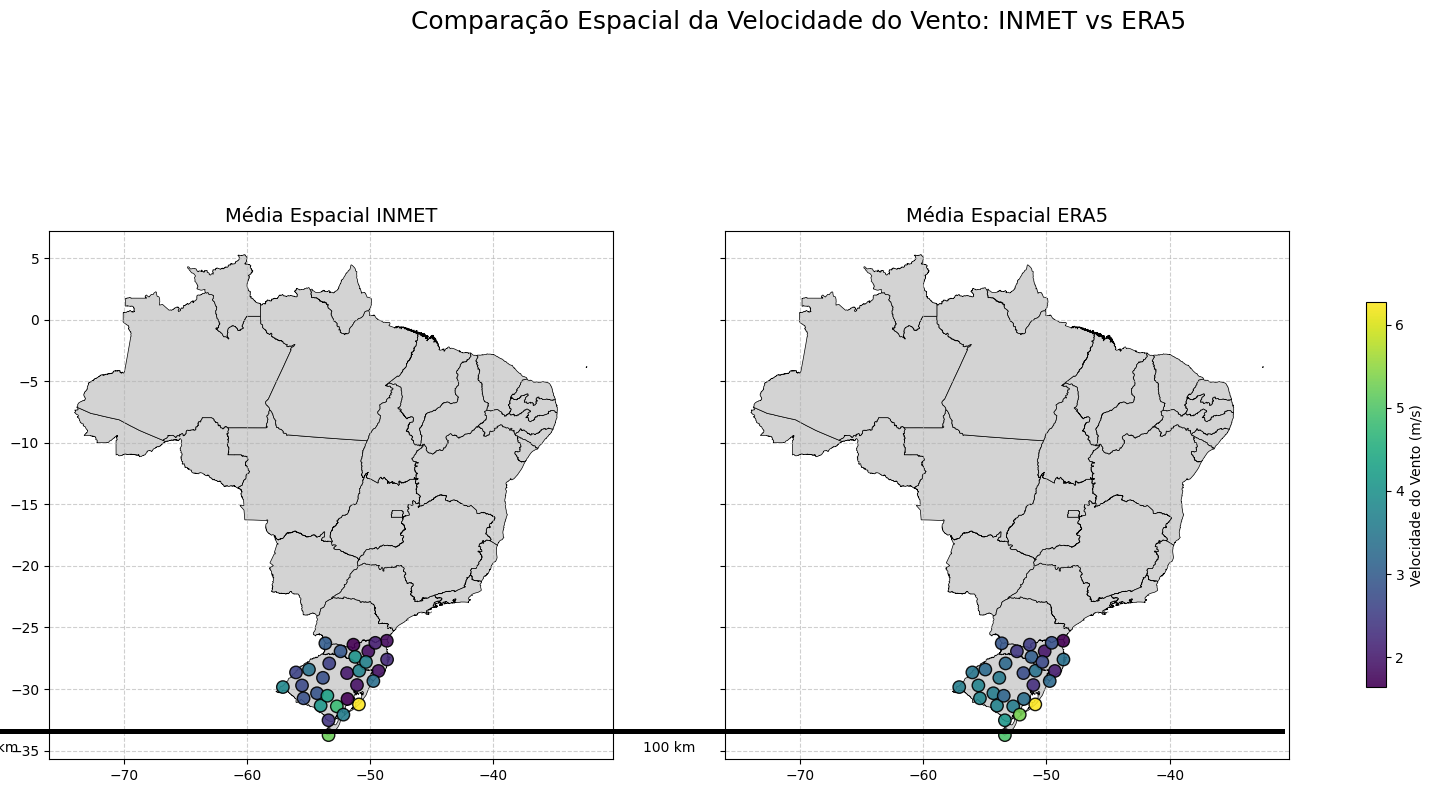

In [7]:
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib_scalebar.scalebar import ScaleBar

# Criando dois subplots para comparação espacial (INMET vs ERA5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

# Lista de datasets agregados e títulos para o loop
plot_configs = [
    (ax1, inmet_spatial, 'Média Espacial INMET'),
    (ax2, era5_spatial, 'Média Espacial ERA5')
]

for ax, data, title in plot_configs:
    # Plotar fronteiras dos estados do Brasil
    brazil_states_gdf.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)

    # Plotar os pontos das estações
    # Usamos as coordenadas do dataset INMET que são as mesmas para as estações fixas
    scatter = ax.scatter(
        ds_inmet['longitude'].values,
        ds_inmet['latitude'].values,
        c=data.values,
        cmap='viridis',
        s=80,
        edgecolors='black',
        alpha=0.9,
        zorder=5
    )

    ax.set_title(title, fontsize=14)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.6)

    # Adicionar barra de escala
    scalebar = ScaleBar(dx=1, units='km', location='lower right', frameon=False, fixed_value=100, rotation='horizontal-only')
    ax.add_artist(scalebar)

# Adicionar uma barra de cores única para ambos os plots
fig.colorbar(scatter, ax=[ax1, ax2], label='Velocidade do Vento (m/s)', orientation='vertical', shrink=0.5)

plt.suptitle('Comparação Espacial da Velocidade do Vento: INMET vs ERA5', fontsize=18)
plt.show()

### Verificação de Consistência dos Dados

Vamos validar se os shapes e as coordenadas de tempo/estação estão alinhados entre os datasets do INMET e ERA5 para garantir que a comparação seja justa.

In [8]:
# Verificando as dimensões dos datasets originais
print(f"Dimensões INMET: {ds_inmet.dims}")
print(f"Dimensões ERA5:  {ds_era5.dims}")

# Verificando se o período temporal coincide
time_start_inmet = ds_inmet.time.min().values
time_end_inmet = ds_inmet.time.max().values
time_start_era5 = ds_era5.time.min().values
time_end_era5 = ds_era5.time.max().values

print(f"\nPeríodo INMET: {time_start_inmet} até {time_end_inmet}")
print(f"Período ERA5:  {time_start_era5} até {time_end_era5}")

# Verificando se o número de estações coincide
print(f"\nNúmero de estações (INMET): {len(ds_inmet.estacao)}")
print(f"Número de estações (ERA5):  {len(ds_era5.estacao)}")

# Checando por valores nulos (NaN) nas variáveis de vento principais
nan_inmet = ds_inmet['daily_wind_speed_mean'].isnull().sum().values
nan_era5 = (ds_era5['10m_u_component_of_wind'].isnull().sum() + ds_era5['10m_v_component_of_wind'].isnull().sum()).values

print(f"\nValores NaN no INMET: {nan_inmet}")
print(f"Valores NaN no ERA5 (componentes u/v): {nan_era5}")

Dimensões INMET: FrozenMappingWarningOnValuesAccess({'time': 1827, 'estacao': 30})
Dimensões ERA5:  FrozenMappingWarningOnValuesAccess({'time': 229991, 'estacao': 30})

Período INMET: 2020-01-01T00:00:00.000000000 até 2024-12-31T00:00:00.000000000
Período ERA5:  2000-01-01T00:00:00.000000000 até 2026-03-27T22:00:00.000000000

Número de estações (INMET): 30
Número de estações (ERA5):  30

Valores NaN no INMET: 6155
Valores NaN no ERA5 (componentes u/v): 1560


### Alinhamento Temporal e Tratamento de Dados Faltantes

Como o ERA5 possui uma janela temporal muito maior e o INMET possui valores nulos, vamos realizar o alinhamento para que a comparação seja feita exatamente no mesmo período e locais.

In [ ]:
import pandas as pd

# 1. Alinhar o ERA5 ao período do INMET
ds_era5_aligned = ds_era5.sel(time=slice(ds_inmet.time.min(), ds_inmet.time.max()))

# 2. Resampler o ERA5 para média diária (caso seja horário)
ds_era5_daily = ds_era5_aligned.resample(time='1D').mean()

# 3. Calcular a magnitude do vento para o ERA5 diário
era5_wind_daily = np.sqrt(ds_era5_daily['10m_u_component_of_wind']**2 + ds_era5_daily['10m_v_component_of_wind']**2)
era5_wind_daily.name = 'wind_speed_era5'

# 4. Sincronizar NaNs: Onde o INMET é NaN, o ERA5 também deve ser ignorado para comparação justa
inmet_wind = ds_inmet['daily_wind_speed_mean']
era5_wind_masked = era5_wind_daily.where(~inmet_wind.isnull())

print(f"Novas dimensões ERA5 (diário/alinhado): {era5_wind_masked.dims}")
print(f"Valores NaN sincronizados no ERA5: {era5_wind_masked.isnull().sum().values}")

## Análise Exploratória de Dados (EDA): INMET vs ERA5

Agora que os dados estão alinhados, vamos comparar o comportamento estatístico das duas fontes de dados.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# 1. Distribuição Global das Velocidades
plt.figure(figsize=(12, 6))
sns.kdeplot(inmet_wind.values.flatten(), label='INMET (Observado)', fill=True, alpha=0.5)
sns.kdeplot(era5_wind_masked.values.flatten(), label='ERA5 (Reanálise)', fill=True, alpha=0.5)
plt.title('Distribuição de Probabilidade da Velocidade do Vento')
plt.xlabel('Velocidade do Vento (m/s)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 2. Comparação Temporal em uma Estação Aleatória
estacao_idx = 0
estacao_nome = ds_inmet.estacao.values[estacao_idx]

plt.figure(figsize=(15, 5))
inmet_wind.isel(estacao=estacao_idx).plot(label='INMET', alpha=0.8)
era5_wind_masked.isel(estacao=estacao_idx).plot(label='ERA5', alpha=0.8)
plt.title(f'Série Temporal de Velocidade do Vento - Estação: {estacao_nome}')
plt.ylabel('Vento (m/s)')
plt.legend()
plt.show()

In [ ]:
# 3. Métricas de Correlação e Erro
# Remover NaNs para cálculo das métricas
mask = ~np.isnan(inmet_wind.values.flatten()) & ~np.isnan(era5_wind_masked.values.flatten())
y_true = inmet_wind.values.flatten()[mask]
y_pred = era5_wind_masked.values.flatten()[mask]

corr = np.corrcoef(y_true, y_pred)[0, 1]
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
bias = np.mean(y_pred - y_true)

print(f"--- Métricas Globais (Alinhadas) ---")
print(f"Correlação de Pearson: {corr:.3f}")
print(f"RMSE: {rmse:.3f} m/s")
print(f"Bias (ERA5 - INMET): {bias:.3f} m/s")

### Divisão Temporal (Train / Val / Test)

Para evitar vazamento de dados (data leakage), vamos separar os dados cronologicamente:
- **Treino**: 2020 - 2022
- **Validação**: 2023
- **Teste**: 2024

In [ ]:
# Definindo os períodos
train_slice = slice('2020-01-01', '2022-12-31')
val_slice = slice('2023-01-01', '2023-12-31')
test_slice = slice('2024-01-01', '2024-12-31')

# Split para o INMET (Target/Observado)
inmet_train = inmet_wind.sel(time=train_slice)
inmet_val = inmet_wind.sel(time=val_slice)
inmet_test = inmet_wind.sel(time=test_slice)

# Split para o ERA5 (Features/Reanálise)
era5_train = era5_wind_masked.sel(time=train_slice)
era5_val = era5_wind_masked.sel(time=val_slice)
era5_test = era5_wind_masked.sel(time=test_slice)

print(f"Treino: {inmet_train.time.size} dias")
print(f"Validação: {inmet_val.time.size} dias")
print(f"Teste: {inmet_test.time.size} dias")

### Verificação do Split por Estação

Como os objetos xarray mantêm as coordenadas, cada conjunto (train/val/test) contém os dados de todas as 30 estações. Vamos visualizar o shape para confirmar.

In [ ]:
# Verificando o shape (Tempo, Estação)
print(f"Shape Treino (INMET): {inmet_train.shape}")
print(f"Shape Validação (INMET): {inmet_val.shape}")
print(f"Shape Teste (INMET): {inmet_test.shape}")

# Exemplo de como acessar uma estação específica ('A801' por exemplo, se existir)
# ou apenas a primeira estação pelo índice
nome_primeira_estacao = inmet_train.estacao.values[0]
dados_estacao_0_treino = inmet_train.isel(estacao=0)

print(f"\nDados de treino para a estação {nome_primeira_estacao}: {dados_estacao_0_treino.size} dias")

### Divisão Espacial (Split por Estações)

Nesta etapa, vamos selecionar aleatoriamente (mas com semente fixa para reprodutibilidade) um grupo de estações para compor o conjunto de teste 'não visto' espacialmente.

In [ ]:
import numpy as np

# Definir semente para reprodutibilidade
np.random.seed(42)

# Obter lista de todas as estações
todas_estacoes = ds_inmet.estacao.values
n_total = len(todas_estacoes)

# Selecionar 20% das estações para teste espacial
n_test = int(0.2 * n_total)
estacoes_teste = np.random.choice(todas_estacoes, n_test, replace=False)
estacoes_treino = np.array([s for s in todas_estacoes if s not in estacoes_teste])

print(f"Estações de Treino ({len(estacoes_treino)}): {estacoes_treino}")
print(f"Estações de Teste ({len(estacoes_teste)}): {estacoes_teste}")

# Criando os datasets filtrados espacialmente
ds_train_spatial = inmet_train.sel(estacao=estacoes_treino)
ds_test_spatial = inmet_test.sel(estacao=estacoes_teste)

print(f"\nShape Final Treino (Tempo, Estação): {ds_train_spatial.shape}")
print(f"Shape Final Teste  (Tempo, Estação): {ds_test_spatial.shape}")

### Ordem Temporal e Timestamps na LSTM

Para responder à sua dúvida: **Sim, a ordem dos dados é preservada.**

A LSTM do Keras espera um input no formato `(batch, timesteps, features)`. No código abaixo:
1.  **Ordenação**: Usamos `df_st.sort_values('time')` para garantir que, para cada estação, os dados estejam em ordem cronológica.
2.  **Janelas (Windowing)**: Criamos sequências de 7 dias consecutivos. O índice `i-window_size:i` garante que o modelo veja o dia 1, depois o dia 2, até o dia 7, antes de prever o alvo.
3.  **Engenharia de Tempo**: Como a LSTM por si só não sabe se 'hoje' é Verão ou Inverno, incluímos as features `day_sin` e `day_cos`. Elas informam ao modelo a posição exata no ciclo anual, ajudando a capturar padrões sazonais de rajadas.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler

# Define the window size for the LSTM model
window_size = 7

def prepare_lstm_data(ds_features, ds_target, target_var='daily_wind_gust_max', window_size=7):
    # 1. Selecionar features do ERA5
    df_feat = ds_features.to_dataframe().reset_index()
    df_targ = ds_target[target_var].to_dataframe().reset_index()

    # Merge e remoção de NaNs - Mantendo a coluna 'time' para ordenação
    df_final = pd.merge(df_feat, df_targ, on=['time', 'estacao'], how='inner').dropna()

    # 2. Engenharia de Features Temporais Cíclicas
    # Transformamos o tempo em sen/cos para que o modelo entenda a continuidade do ciclo anual
    day_of_year = df_final['time'].dt.dayofyear
    df_final['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df_final['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)

    # Feature de magnitude física do vento
    df_final['wind_mag'] = np.sqrt(df_final['10m_u_component_of_wind']**2 + df_final['10m_v_component_of_wind']**2)

    # Aqui definimos as colunas que o modelo REALMENTE verá (incluindo as temporais)
    features_cols = [
        '10m_u_component_of_wind',
        '10m_v_component_of_wind',
        'wind_mag',
        '2m_temperature',
        'surface_pressure',
        'day_sin',
        'day_cos'  # <--- Features temporais passadas ao modelo
    ]

    # 3. Normalização e Estruturação de Sequências
    scaler_x = RobustScaler()
    scaler_y = RobustScaler()

    X_data, y_data = [], []

    for st in df_final['estacao'].unique():
        df_st = df_final[df_final['estacao'] == st].sort_values('time')
        if len(df_st) < window_size: continue

        st_feat = scaler_x.fit_transform(df_st[features_cols])
        st_targ = scaler_y.fit_transform(df_st[[target_var]])

        for i in range(window_size, len(df_st)):
            X_data.append(st_feat[i-window_size:i])
            y_data.append(st_targ[i])

    return np.array(X_data), np.array(y_data), scaler_x, scaler_y

# Re-preparando os dados para garantir que as novas features temporais sejam incluídas
X_train, y_train, s_x, s_y = prepare_lstm_data(ds_era5_daily.sel(estacao=estacoes_treino, time=train_slice), ds_inmet.sel(estacao=estacoes_treino, time=train_slice), window_size=window_size)
print(f"Dados preparados com features temporais cíclicas: {X_train.shape}")

### Cálculo da Climatologia e Detrending

Nesta etapa, calculamos a média histórica diária para cada estação no período de treino. Isso servirá como nosso 'ponto zero'.

In [ ]:
def prepare_lstm_seasonal_no_ids(ds_features, ds_target, ds_clim, window_size=7):
    df_feat = ds_features.to_dataframe().reset_index()
    df_targ = ds_target[['daily_wind_gust_max']].to_dataframe().reset_index()
    df_targ['dayofyear'] = df_targ['time'].dt.dayofyear
    df_clim_df = ds_clim.to_dataframe(name='clim_value').reset_index()

    # Unindo dados sem gerar variáveis dummy de estação
    df_merged = pd.merge(df_feat, df_targ, on=['time', 'estacao'], how='inner')
    df_merged = pd.merge(df_merged, df_clim_df, on=['dayofyear', 'estacao'], how='left')
    df_merged['target_anomaly'] = df_merged['daily_wind_gust_max'] - df_merged['clim_value']
    df_merged = df_merged.dropna().sort_values(['estacao', 'time'])

    # Engenharia de Features
    day_of_year = df_merged['time'].dt.dayofyear
    df_merged['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df_merged['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)
    df_merged['wind_mag'] = np.sqrt(df_merged['10m_u_component_of_wind']**2 + df_merged['10m_v_component_of_wind']**2)

    def get_season(month):
        if month in [12, 1, 2]: return 'DJF'
        if month in [3, 4, 5]: return 'MAM'
        if month in [6, 7, 8]: return 'JJA'
        return 'SON'
    df_merged['season'] = df_merged['time'].dt.month.map(get_season)

    # Apenas as 7 variáveis climáticas/temporais fundamentais
    base_features = ['10m_u_component_of_wind', '10m_v_component_of_wind', 'wind_mag', '2m_temperature', 'surface_pressure', 'day_sin', 'day_cos']

    seasonal_data = {s: [] for s in ['DJF', 'MAM', 'JJA', 'SON']}
    seasonal_targets = {s: [] for s in ['DJF', 'MAM', 'JJA', 'SON']}
    seasonal_clim = {s: [] for s in ['DJF', 'MAM', 'JJA', 'SON']}

    scaler_x = RobustScaler()
    scaler_y = RobustScaler()

    scaler_x.fit(df_merged[base_features])
    scaler_y.fit(df_merged[['target_anomaly']])

    for st in df_merged['estacao'].unique():
        df_st = df_merged[df_merged['estacao'] == st]
        if len(df_st) < window_size: continue

        st_feat = scaler_x.transform(df_st[base_features])
        st_targ = scaler_y.transform(df_st[['target_anomaly']])
        st_clim = df_st['clim_value'].values
        seasons = df_st['season'].values

        for i in range(window_size, len(df_st)):
            s = seasons[i]
            seasonal_data[s].append(st_feat[i-window_size:i])
            seasonal_targets[s].append(st_targ[i])
            seasonal_clim[s].append(st_clim[i])

    return {s: np.array(v) for s, v in seasonal_data.items()}, \
           {s: np.array(v) for s, v in seasonal_targets.items()}, \
           {s: np.array(v) for s, v in seasonal_clim.items()}, scaler_x, scaler_y

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.preprocessing import RobustScaler

# 1. Definir o mapeamento de estações para clusters
def get_station_clusters(ds_inmet):
    shp_path = '/content/drive/MyDrive/- IRB/Vendaval-IA/dataset/shp'
    shp_files = [f for f in os.listdir(shp_path) if f.endswith('.shp')]
    clusters_gdf = gpd.read_file(os.path.join(shp_path, shp_files[0]))
    if clusters_gdf.crs is None or clusters_gdf.crs != 'epsg:4326':
        clusters_gdf = clusters_gdf.set_crs('epsg:4326', allow_override=True)

    stations_df = ds_inmet[['latitude', 'longitude']].to_dataframe().groupby('estacao').first().reset_index()
    stations_gdf = gpd.GeoDataFrame(stations_df, geometry=gpd.points_from_xy(stations_df.longitude, stations_df.latitude), crs='EPSG:4326')
    return gpd.sjoin(stations_gdf, clusters_gdf, predicate='within', how='left')

# 2. Função base para preparar dados LSTM com suporte a clusters
def prepare_lstm_data_with_clusters(ds_features, ds_target, stations_cluster_df, target_var='daily_wind_gust_max', window_size=7):
    df_feat = ds_features.to_dataframe().reset_index()
    df_targ = ds_target[target_var].to_dataframe().reset_index()
    df_final = pd.merge(df_feat, df_targ, on=['time', 'estacao'], how='inner').dropna()

    cluster_col_name = [c for c in stations_cluster_df.columns if 'cluster' in c.lower() or 'id' in c.lower()][0]
    df_final = pd.merge(df_final, stations_cluster_df[['estacao', cluster_col_name]], on='estacao', how='left')

    df_clusters = pd.get_dummies(df_final[cluster_col_name], prefix='cluster')
    cluster_cols = df_clusters.columns.tolist()
    df_final = pd.concat([df_final, df_clusters], axis=1)

    day_of_year = df_final['time'].dt.dayofyear
    df_final['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df_final['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)
    df_final['wind_mag'] = np.sqrt(df_final['10m_u_component_of_wind']**2 + df_final['10m_v_component_of_wind']**2)

    base_features = ['10m_u_component_of_wind', '10m_v_component_of_wind', 'wind_mag', '2m_temperature', 'surface_pressure', 'day_sin', 'day_cos']

    X_data, y_data = [], []
    s_x, s_y = RobustScaler(), RobustScaler()

    for st in df_final['estacao'].unique():
        df_st = df_final[df_final['estacao'] == st].sort_values('time')
        if len(df_st) < window_size: continue
        st_feat_numeric = s_x.fit_transform(df_st[base_features])
        st_feat_combined = np.hstack([st_feat_numeric, df_st[cluster_cols].values])
        st_targ = s_y.fit_transform(df_st[[target_var]])
        for i in range(window_size, len(df_st)):
            X_data.append(st_feat_combined[i-window_size:i])
            y_data.append(st_targ[i])

    return np.array(X_data), np.array(y_data), base_features + cluster_cols

# 3. Funções de preparação sazonal e partição
def prepare_seasonal_cluster_data(ds_feat, ds_targ, stations_cluster_df, window_size=7):
    seasonal_X, seasonal_y = {}, {}
    for s in ['DJF', 'MAM', 'JJA', 'SON']:
        months = [12, 1, 2] if s == 'DJF' else [3, 4, 5] if s == 'MAM' else [6, 7, 8] if s == 'JJA' else [9, 10, 11]
        ds_f = ds_feat.sel(time=ds_feat.time.dt.month.isin(months))
        ds_t = ds_targ.sel(time=ds_targ.time.dt.month.isin(months))
        if ds_f.time.size < window_size:
            seasonal_X[s], seasonal_y[s] = np.array([]), np.array([])
            continue
        X, y, _ = prepare_lstm_data_with_clusters(ds_f, ds_t, stations_cluster_df, window_size=window_size)
        seasonal_X[s], seasonal_y[s] = X, y
    return seasonal_X, seasonal_y

def prepare_dual_specialty_data(seasonal_data, seasonal_targets, extreme_threshold=1.5):
    dual_data = {}
    for season, X in seasonal_data.items():
        y = seasonal_targets[season]
        if len(X) == 0: continue
        mask_ext = (y > extreme_threshold).flatten()
        dual_data[f'{season}_Normal'] = (X[~mask_ext], y[~mask_ext])
        dual_data[f'{season}_Extreme'] = (X[mask_ext], y[mask_ext])
        print(f'{season}: Normal: {len(y[~mask_ext])} | Extreme: {len(y[mask_ext])}')
    return dual_data

# 4. Execução do pipeline
stations_with_clusters = get_station_clusters(ds_inmet)
print('--- Preparando Dados Sazonais por Cluster ---')
X_train_sc, y_train_sc = prepare_seasonal_cluster_data(ds_era5_daily.sel(estacao=estacoes_treino, time=train_slice), ds_inmet.sel(estacao=estacoes_treino, time=train_slice), stations_with_clusters)
X_val_sc, y_val_sc = prepare_seasonal_cluster_data(ds_era5_daily.sel(estacao=estacoes_treino, time=val_slice), ds_inmet.sel(estacao=estacoes_treino, time=val_slice), stations_with_clusters)

print('\n--- Divisão Dual Specialty ---')
train_dual = prepare_dual_specialty_data(X_train_sc, y_train_sc)
val_dual = prepare_dual_specialty_data(X_val_sc, y_val_sc)

### Próximo Passo: Treinamento dos 8 Especialistas

Agora que temos os dados divididos, o plano é:
1.  **Modelos Normais**: Treinados com a perda padrão (`mae` ou `huber`) para estabilidade.
2.  **Modelos de Extremos**: Treinados com a `robust_extreme_loss` (peso 20x) para máxima sensibilidade.

Podemos prosseguir com o loop de treinamento para esses 8 modelos?

In [ ]:
def get_climatology(ds_target, target_var='daily_wind_gust_max'):
    # Média por dia do ano (1-366) para cada estação individualmente
    return ds_target[target_var].groupby('time.dayofyear').mean(dim='time')

# Calculamos a climatologia apenas com dados de TREINO para evitar data leakage
ds_climatology = get_climatology(ds_inmet.sel(time=train_slice))

print("Climatologia calculada. Exemplo para a primeira estação:")
display(ds_climatology.isel(estacao=0))

In [ ]:
def prepare_lstm_data_detrended(ds_features, ds_target, ds_clim, target_var='daily_wind_gust_max', window_size=7):
    df_feat = ds_features.to_dataframe().reset_index()
    df_targ = ds_target[target_var].to_dataframe().reset_index()

    # Adicionar dia do ano para cruzar com a climatologia
    df_targ['dayofyear'] = df_targ['time'].dt.dayofyear
    df_clim_df = ds_clim.to_dataframe(name='clim_value').reset_index()

    # Merge das features, target e climatologia
    df_merged = pd.merge(df_feat, df_targ, on=['time', 'estacao'], how='inner')
    df_merged = pd.merge(df_merged, df_clim_df, on=['dayofyear', 'estacao'], how='left')

    # Cálculo do Resíduo (Anomalia)
    df_merged['target_anomaly'] = df_merged[target_var] - df_merged['clim_value']
    df_merged = df_merged.dropna()

    # Features Temporais e Magnitude
    day_of_year = df_merged['time'].dt.dayofyear
    df_merged['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df_merged['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)
    df_merged['wind_mag'] = np.sqrt(df_merged['10m_u_component_of_wind']**2 + df_merged['10m_v_component_of_wind']**2)

    features_cols = ['10m_u_component_of_wind', '10m_v_component_of_wind', 'wind_mag', '2m_temperature', 'surface_pressure', 'day_sin', 'day_cos']

    scaler_x = RobustScaler()
    scaler_y = RobustScaler() # Scaler para a anomalia

    X_data, y_data, clim_vals = [], [], []

    for st in df_merged['estacao'].unique():
        df_st = df_merged[df_merged['estacao'] == st].sort_values('time')
        if len(df_st) < window_size: continue

        st_feat = scaler_x.fit_transform(df_st[features_cols])
        st_targ = scaler_y.fit_transform(df_st[['target_anomaly']])
        st_clim = df_st['clim_value'].values

        for i in range(window_size, len(df_st)):
            X_data.append(st_feat[i-window_size:i])
            y_data.append(st_targ[i])
            clim_vals.append(st_clim[i])

    return np.array(X_data), np.array(y_data), np.array(clim_vals), scaler_x, scaler_y

# Novos conjuntos de dados baseados em anomalias
X_train_dt, y_train_dt, _, s_x_dt, s_y_dt = prepare_lstm_data_detrended(
    ds_era5_daily.sel(estacao=estacoes_treino, time=train_slice),
    ds_inmet.sel(estacao=estacoes_treino, time=train_slice),
    ds_climatology
)

print(f"Dados com remoção de baseline prontos. Novo target: Anomalia.")
print(f"Shape X_train_dt: {X_train_dt.shape}")

In [ ]:
# Inspeção dos dados para confirmar as features temporais cíclicas
feature_names = ['u_wind', 'v_wind', 'magnitude', 'temp', 'pres', 'day_sin', 'day_cos']

print(f"Formato do X_train: {X_train.shape} (Amostras, Timesteps, Features)")
print("\nExemplo de 1 amostra (primeiro passo de tempo) mostrando todas as features:")
for name, value in zip(feature_names, X_train[0, 0, :]):
    print(f"{name:10}: {value:.4f}")

print("\nIsso confirma que 'day_sin' e 'day_cos' estão presentes no tensor enviado ao modelo.")

### Adicionando Identidade das Estações (One-Hot Encoding)

Para garantir que o modelo não se confunda entre diferentes localizações geográficas, vamos incluir colunas identificadoras para cada estação. Isso permite que a LSTM aprenda 'vieses' específicos de cada sensor.

In [ ]:
def prepare_lstm_data_with_ids(ds_features, ds_target, target_var='daily_wind_gust_max', window_size=7):
    df_feat = ds_features.to_dataframe().reset_index()
    df_targ = ds_target[target_var].to_dataframe().reset_index()
    df_final = pd.merge(df_feat, df_targ, on=['time', 'estacao'], how='inner').dropna()

    # 1. Criar variáveis Dummy (One-Hot) para as estações
    # Isso cria uma coluna para cada estação (Ex: estacao_A801, estacao_A802...)
    df_stations = pd.get_dummies(df_final['estacao'], prefix='st')
    df_final = pd.concat([df_final, df_stations], axis=1)

    station_cols = df_stations.columns.tolist()

    # 2. Features Temporais e Magnitude
    day_of_year = df_final['time'].dt.dayofyear
    df_final['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df_final['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)
    df_final['wind_mag'] = np.sqrt(df_final['10m_u_component_of_wind']**2 + df_final['10m_v_component_of_wind']**2)

    base_features = ['10m_u_component_of_wind', '10m_v_component_of_wind', 'wind_mag', '2m_temperature', 'surface_pressure', 'day_sin', 'day_cos']

    # A lista final de features agora inclui os IDs das estações
    full_features = base_features + station_cols

    X_data, y_data = [], []
    scaler_x = RobustScaler()
    scaler_y = RobustScaler()

    for st in df_final['estacao'].unique():
        df_st = df_final[df_final['estacao'] == st].sort_values('time')
        if len(df_st) < window_size: continue

        # Normalizamos apenas as colunas numéricas, mantendo as dummies (0 e 1) intactas
        st_feat_numeric = scaler_x.fit_transform(df_st[base_features])
        st_feat_ids = df_st[station_cols].values

        # Combinamos as features numéricas escalonadas com os IDs
        st_feat_combined = np.hstack([st_feat_numeric, st_feat_ids])
        st_targ = scaler_y.fit_transform(df_st[[target_var]])

        for i in range(window_size, len(df_st)):
            X_data.append(st_feat_combined[i-window_size:i])
            y_data.append(st_targ[i])

    print(f"Total de features: {len(full_features)} (7 climáticas + {len(station_cols)} IDs de estações)")
    return np.array(X_data), np.array(y_data), full_features

X_train_id, y_train_id, feature_list = prepare_lstm_data_with_ids(ds_era5_daily.sel(estacao=estacoes_treino, time=train_slice), ds_inmet.sel(estacao=estacoes_treino, time=train_slice))
print(f"Novo shape do input: {X_train_id.shape}")

In [ ]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Listar e carregar os shapefiles de clusters
shp_path = '/content/drive/MyDrive/- IRB/Vendaval-IA/dataset/shp'
shp_files = [f for f in os.listdir(shp_path) if f.endswith('.shp')]
print(f"Shapefiles encontrados: {shp_files}")

# Vamos carregar o primeiro shapefile encontrado (ajuste o nome se necessário)
clusters_gdf = gpd.read_file(os.path.join(shp_path, shp_files[0]))

# Garantir que o CRS seja compatível (WGS84)
if clusters_gdf.crs is None or clusters_gdf.crs != 'epsg:4326':
    clusters_gdf = clusters_gdf.set_crs('epsg:4326', allow_override=True)

# 2. Criar um GeoDataFrame para as Estações
stations_df = ds_inmet[['latitude', 'longitude']].to_dataframe().groupby('estacao').first().reset_index()
stations_gdf = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(stations_df.longitude, stations_df.latitude),
    crs="EPSG:4326"
)

# 3. Spatial Join: Identificar em qual cluster cada estação cai
# 'op' depende da versão do geopandas, usando 'predicate' para compatibilidade
stations_with_clusters = gpd.sjoin(stations_gdf, clusters_gdf, predicate='within', how='left')

# Exibir mapeamento
display(stations_with_clusters[['estacao', 'id_cluster' if 'id_cluster' in stations_with_clusters.columns else clusters_gdf.columns[0]]].head())

# 4. Visualização
fig, ax = plt.subplots(figsize=(10, 10))
brazil_states_gdf.plot(ax=ax, color='white', edgecolor='gray', alpha=0.5)
clusters_gdf.plot(ax=ax, column=clusters_gdf.columns[0], cmap='tab10', alpha=0.4, legend=True)
stations_gdf.plot(ax=ax, color='red', markersize=50, label='Estações')
plt.title("Distribuição das Estações e Clusters Climáticos")
plt.legend()
plt.show()

In [ ]:
def prepare_lstm_data_with_clusters(ds_features, ds_target, stations_cluster_df, target_var='daily_wind_gust_max', window_size=7):
    df_feat = ds_features.to_dataframe().reset_index()
    df_targ = ds_target[target_var].to_dataframe().reset_index()

    # Merge das variáveis e NaNs
    df_final = pd.merge(df_feat, df_targ, on=['time', 'estacao'], how='inner').dropna()

    # Integrar informação de Cluster (ajuste o nome da coluna de cluster conforme o print anterior)
    cluster_col_name = [c for c in stations_cluster_df.columns if 'cluster' in c.lower() or 'id' in c.lower()][0]
    df_final = pd.merge(df_final, stations_cluster_df[['estacao', cluster_col_name]], on='estacao', how='left')

    # One-Hot Encoding dos Clusters
    df_clusters = pd.get_dummies(df_final[cluster_col_name], prefix='cluster')
    cluster_cols = df_clusters.columns.tolist()
    df_final = pd.concat([df_final, df_clusters], axis=1)

    # Features Temporais e Magnitude
    day_of_year = df_final['time'].dt.dayofyear
    df_final['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df_final['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)
    df_final['wind_mag'] = np.sqrt(df_final['10m_u_component_of_wind']**2 + df_final['10m_v_component_of_wind']**2)

    base_features = ['10m_u_component_of_wind', '10m_v_component_of_wind', 'wind_mag', '2m_temperature', 'surface_pressure', 'day_sin', 'day_cos']
    full_features = base_features + cluster_cols

    X_data, y_data = [], []
    scaler_x = RobustScaler()
    scaler_y = RobustScaler()

    for st in df_final['estacao'].unique():
        df_st = df_final[df_final['estacao'] == st].sort_values('time')
        if len(df_st) < window_size: continue

        st_feat_numeric = scaler_x.fit_transform(df_st[base_features])
        st_feat_clusters = df_st[cluster_cols].values

        st_feat_combined = np.hstack([st_feat_numeric, st_feat_clusters])
        st_targ = scaler_y.fit_transform(df_st[[target_var]])

        for i in range(window_size, len(df_st)):
            X_data.append(st_feat_combined[i-window_size:i])
            y_data.append(st_targ[i])

    print(f"Total de features: {len(full_features)} (7 climáticas + {len(cluster_cols)} Clusters)")
    return np.array(X_data), np.array(y_data), full_features

# Preparando os dados com os clusters
X_train_cluster, y_train_cluster, feature_list_cluster = prepare_lstm_data_with_clusters(
    ds_era5_daily.sel(estacao=estacoes_treino, time=train_slice),
    ds_inmet.sel(estacao=estacoes_treino, time=train_slice),
    stations_with_clusters
)
print(f"Novo shape com clusters: {X_train_cluster.shape}")

In [ ]:
# 1. Preparar os dados sazonais usando a nova função com Clusters
def prepare_seasonal_cluster_data(ds_feat, ds_targ, stations_cluster_df, window_size=7):
    # Re-utilizamos a lógica de extração mas agora com a função que inclui clusters
    # Nota: a função prepare_lstm_data_with_clusters já faz o merge e limpeza

    seasonal_X, seasonal_y = {}, {}
    for s in ['DJF', 'MAM', 'JJA', 'SON']:
        # Filtro: pegamos os meses correspondentes no dataset
        months = [12, 1, 2] if s == 'DJF' else [3, 4, 5] if s == 'MAM' else [6, 7, 8] if s == 'JJA' else [9, 10, 11]
        ds_feat_s = ds_feat.sel(time=ds_feat.time.dt.month.isin(months))
        ds_targ_s = ds_targ.sel(time=ds_targ.time.dt.month.isin(months))

        # Processa cada estação dentro da estação climática
        X, y, _ = prepare_lstm_data_with_clusters(ds_feat_s, ds_targ_s, stations_cluster_df, window_size=window_size)
        seasonal_X[s] = X
        seasonal_y[s] = y

    return seasonal_X, seasonal_y

# 2. Preparar dados de treino e validação com os Clusters
X_train_sc, y_train_sc = prepare_seasonal_cluster_data(
    ds_era5_daily.sel(estacao=estacoes_treino, time=train_slice),
    ds_inmet.sel(estacao=estacoes_treino, time=train_slice),
    stations_with_clusters
)

X_val_sc, y_val_sc = prepare_seasonal_cluster_data(
    ds_era5_daily.sel(estacao=estacoes_treino, time=val_slice),
    ds_inmet.sel(estacao=estacoes_treino, time=val_slice),
    stations_with_clusters
)

# 3. Dividir em Normal/Extreme (usando a função de partição já definida anteriormente)
train_dual_cluster = prepare_dual_specialty_data(X_train_sc, y_train_sc)
val_dual_cluster = prepare_dual_specialty_data(X_val_sc, y_val_sc)

print("Dados preparados com sucesso utilizando os clusters climáticos!")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import tensorflow.keras.backend as K

# 1. Definição da Perda Customizada para Extremos
def robust_extreme_loss(y_true, y_pred):
    error = y_true - y_pred
    logcosh = tf.math.log(tf.math.cosh(error + 1e-12))
    weights = tf.where(y_true > 1.5, 20.0, 1.0)
    return K.mean(logcosh * weights)

specialty_configs = [
    {'type': 'Normal', 'loss': tf.keras.losses.Huber(), 'epochs': 40, 'batch': 64},
    {'type': 'Extreme', 'loss': robust_extreme_loss, 'epochs': 60, 'batch': 32}
]

# 2. Identificar clusters únicos
cluster_col = [c for c in stations_with_clusters.columns if 'cluster' in c.lower() or 'id' in c.lower()][0]
unique_clusters = sorted(stations_with_clusters[cluster_col].unique())

# Dicionário para armazenar os modelos: {cluster_id: {spec_name: model}}
dual_models_by_cluster = {}

for cluster_id in unique_clusters:
    print(f"\n=== Treinando Especialistas para o CLUSTER {cluster_id} ===")
    dual_models_by_cluster[cluster_id] = {}

    # Pegar as estações que pertencem a este cluster
    st_in_cluster = stations_with_clusters[stations_with_clusters[cluster_col] == cluster_id]['estacao'].values

    for season in ['DJF', 'MAM', 'JJA', 'SON']:
        # Filtrar dados de treino e val para as estações deste cluster específico
        # Nota: Como train_dual_cluster já foi preparado, filtramos por cluster_id usando as colunas dummy correspondentes
        cluster_feature_idx = feature_list_cluster.index(f'cluster_{cluster_id}')

        for spec in specialty_configs:
            spec_name = f"{season}_{spec['type']}"

            X_tr_all, y_tr_all = train_dual_cluster[spec_name]
            X_vl_all, y_vl_all = val_dual_cluster[spec_name]

            # Máscara para selecionar apenas amostras onde a dummy do cluster atual é 1
            # X shape: (samples, timesteps, features). Olhamos o último timestep para o ID.
            mask_tr = X_tr_all[:, -1, cluster_feature_idx] == 1
            mask_vl = X_vl_all[:, -1, cluster_feature_idx] == 1

            X_tr, y_tr = X_tr_all[mask_tr], y_tr_all[mask_tr]
            X_vl, y_vl = X_vl_all[mask_vl], y_vl_all[mask_vl]

            if len(X_tr) < 10:
                print(f"Pulando {spec_name}: Dados insuficientes ({len(X_tr)} amostras).")
                continue

            print(f"Treinando {spec_name} ({len(X_tr)} amostras)... ", end='')

            model = Sequential([
                Input(shape=(X_tr.shape[1], X_tr.shape[2])),
                LSTM(64 if spec['type'] == 'Extreme' else 32, return_sequences=False, kernel_regularizer=l2(0.01)),
                BatchNormalization(),
                Dense(16, activation='elu'),
                Dropout(0.4),
                Dense(1)
            ])

            model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss=spec['loss'])

            model.fit(
                X_tr, y_tr,
                validation_data=(X_vl, y_vl) if len(X_vl) > 0 else None,
                epochs=spec['epochs'],
                batch_size=spec['batch'],
                verbose=0,
                callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
            )

            dual_models_by_cluster[cluster_id][spec_name] = model
            print("OK")

print("\nSucesso: Modelos treinados individualmente por Cluster!")

### Avaliação no Teste Espacial (Estações não vistas)

Agora vamos usar o modelo para prever as rajadas nas estações de teste e comparar com os valores reais do INMET.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

def evaluate_granular_performance(X_test_dict, y_test_dict, clim_test_dict, cluster_models, scaler_y, extreme_threshold=1.5):
    results = []

    for cluster_id in sorted(cluster_models.keys()):
        cluster_str = f'cluster_{cluster_id}'
        if cluster_str not in feature_list_cluster:
            continue

        cluster_col_idx = feature_list_cluster.index(cluster_str)

        for season in ['DJF', 'MAM', 'JJA', 'SON']:
            if season not in X_test_dict or len(X_test_dict[season]) == 0:
                continue

            X_all = X_test_dict[season].astype('float32')
            y_all = y_test_dict[season].astype('float32')
            clim_all = np.array(clim_test_dict[season]).astype('float32')

            min_len = min(len(X_all), len(y_all), len(clim_all))
            X_all, y_all, clim_all = X_all[:min_len], y_all[:min_len], clim_all[:min_len]

            cluster_mask = (X_all[:, -1, cluster_col_idx] == 1)

            if not np.any(cluster_mask):
                continue

            X_c, y_c, clim_c = X_all[cluster_mask], y_all[cluster_mask], clim_all[cluster_mask]

            model_norm = cluster_models[cluster_id].get(f"{season}_Normal")
            model_ext = cluster_models[cluster_id].get(f"{season}_Extreme")

            if model_norm is None: continue

            y_pred_norm_scaled = model_norm.predict(X_c, verbose=0)
            final_y_pred_scaled = y_pred_norm_scaled.copy()

            if model_ext is not None:
                mask_is_ext = (y_pred_norm_scaled > extreme_threshold).flatten()
                if np.any(mask_is_ext):
                    final_y_pred_scaled[mask_is_ext] = model_ext.predict(X_c[mask_is_ext], verbose=0)

            y_pred_abs = scaler_y.inverse_transform(final_y_pred_scaled).flatten() + clim_c
            y_true_abs = scaler_y.inverse_transform(y_c).flatten() + clim_c

            results.append({
                'Cluster': cluster_id,
                'Season': season,
                'Samples': len(y_true_abs),
                'RMSE': round(np.sqrt(mean_squared_error(y_true_abs, y_pred_abs)), 3),
                'Corr': round(np.corrcoef(y_true_abs, y_pred_abs)[0, 1], 3) if len(y_true_abs) > 1 else 0
            })

    return pd.DataFrame(results)

def prepare_test_sc_consistent(ds_feat, ds_targ, ds_clim, stations_cluster_df, reference_features, window_size=7):
    df_feat = ds_feat.to_dataframe().reset_index()
    df_targ = ds_targ[['daily_wind_gust_max']].to_dataframe().reset_index()
    df_targ['dayofyear'] = df_targ['time'].dt.dayofyear
    df_clim_df = ds_clim.to_dataframe(name='clim_value').reset_index()

    cluster_col_name = [c for c in stations_cluster_df.columns if 'cluster' in c.lower() or 'id' in c.lower()][0]

    df_final = pd.merge(df_feat, df_targ, on=['time', 'estacao'])
    df_final = pd.merge(df_final, df_clim_df, on=['dayofyear', 'estacao'], how='left')
    df_final = pd.merge(df_final, stations_cluster_df[['estacao', cluster_col_name]], on='estacao').dropna()

    df_final['target_anomaly'] = df_final['daily_wind_gust_max'] - df_final['clim_value']

    df_clusters = pd.get_dummies(df_final[cluster_col_name], prefix='cluster')
    for col in [c for c in reference_features if 'cluster_' in c]:
        if col not in df_clusters.columns:
            df_clusters[col] = 0

    df_final = pd.concat([df_final, df_clusters], axis=1)

    day_of_year = df_final['time'].dt.dayofyear
    df_final['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df_final['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)
    df_final['wind_mag'] = np.sqrt(df_final['10m_u_component_of_wind']**2 + df_final['10m_v_component_of_wind']**2)

    def get_season(m): return 'DJF' if m in [12,1,2] else 'MAM' if m in [3,4,5] else 'JJA' if m in [6,7,8] else 'SON'
    df_final['season'] = df_final['time'].dt.month.map(get_season)

    base_features = ['10m_u_component_of_wind', '10m_v_component_of_wind', 'wind_mag', '2m_temperature', 'surface_pressure', 'day_sin', 'day_cos']
    cluster_cols = [c for c in reference_features if 'cluster_' in c]

    seasonal_X, seasonal_y, seasonal_clim = {s: [] for s in ['DJF', 'MAM', 'JJA', 'SON']}, {s: [] for s in ['DJF', 'MAM', 'JJA', 'SON']}, {s: [] for s in ['DJF', 'MAM', 'JJA', 'SON']}

    for st in df_final['estacao'].unique():
        df_st = df_final[df_final['estacao'] == st].sort_values('time')
        if len(df_st) < window_size: continue

        st_feat = np.hstack([s_x_dt.transform(df_st[base_features]), df_st[cluster_cols].values.astype(float)])
        st_targ = s_y_dt.transform(df_st[['target_anomaly']])
        st_clim = df_st['clim_value'].values

        for i in range(window_size, len(df_st)):
            s = df_st['season'].iloc[i]
            seasonal_X[s].append(st_feat[i-window_size:i])
            seasonal_y[s].append(st_targ[i])
            seasonal_clim[s].append(st_clim[i])

    return {s: np.array(v, dtype='float32') for s, v in seasonal_X.items()}, \
           {s: np.array(v, dtype='float32') for s, v in seasonal_y.items()}, \
           {s: np.array(v, dtype='float32') for s, v in seasonal_clim.items()}

X_test_sc, y_test_sc, clim_test_sc = prepare_test_sc_consistent(
    ds_era5_daily.sel(estacao=estacoes_teste, time=test_slice),
    ds_inmet.sel(estacao=estacoes_teste, time=test_slice),
    ds_climatology,
    stations_with_clusters, feature_list_cluster
)

df_metrics_granular = evaluate_granular_performance(
    X_test_sc, y_test_sc, clim_test_sc, dual_models_by_cluster, s_y_dt
)

print("--- Avaliação Granular Concluída ---")
display(df_metrics_granular.sort_values(['Cluster', 'Season']))

### Análise de Diagnóstico por Cluster

Nesta seção, geramos gráficos de dispersão e distribuição de resíduos para cada cluster individualmente, permitindo uma inspeção visual detalhada da performance do pipeline Dual-Specialty.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error

def plot_cluster_diagnostics_seasonal(X_test_dict, y_test_dict, clim_test_dict, cluster_models, scaler_y, cluster_id, extreme_threshold=1.5):
    cluster_str = f'cluster_{cluster_id}'
    cluster_col_idx = feature_list_cluster.index(cluster_str)
    seasons = ['DJF', 'MAM', 'JJA', 'SON']

    # Filtrar quais estações realmente possuem dados para este cluster para planejar o grid
    available_seasons = []
    for s in seasons:
        if s in X_test_dict and len(X_test_dict[s]) > 0:
            X_all = X_test_dict[s].astype('float32')
            cluster_mask = (X_all[:, -1, cluster_col_idx] == 1)
            if np.any(cluster_mask):
                available_seasons.append(s)

    if not available_seasons:
        return # Pula o cluster inteiro se não houver dados em nenhuma estação

    # Criar figura apenas com o número de linhas necessárias
    n_rows = len(available_seasons)
    fig, axes = plt.subplots(n_rows, 2, figsize=(15, 5 * n_rows), squeeze=False)
    plt.suptitle(f'Diagnóstico Detalhado - CLUSTER {cluster_id}', fontsize=20, y=1.02)

    for i, season in enumerate(available_seasons):
        ax_scatter = axes[i, 0]
        ax_hist = axes[i, 1]

        # Processamento de dados
        X_all = X_test_dict[season].astype('float32')
        y_all = y_test_dict[season].astype('float32')
        clim_all = np.array(clim_test_dict[season]).astype('float32')

        min_len = min(len(X_all), len(y_all), len(clim_all))
        X_all, y_all, clim_all = X_all[:min_len], y_all[:min_len], clim_all[:min_len]

        cluster_mask = (X_all[:, -1, cluster_col_idx] == 1)
        X_c, y_c, clim_c = X_all[cluster_mask], y_all[cluster_mask], clim_all[cluster_mask]

        # Predição
        model_norm = cluster_models[cluster_id].get(f"{season}_Normal")
        model_ext = cluster_models[cluster_id].get(f"{season}_Extreme")

        if model_norm is None:
            ax_scatter.text(0.5, 0.5, f'Modelo Normal ausente', ha='center', va='center')
            continue

        y_pred_norm_scaled = model_norm.predict(X_c, verbose=0)
        final_y_pred_scaled = y_pred_norm_scaled.copy()

        if model_ext is not None:
            mask_is_ext = (y_pred_norm_scaled > extreme_threshold).flatten()
            if np.any(mask_is_ext):
                final_y_pred_scaled[mask_is_ext] = model_ext.predict(X_c[mask_is_ext], verbose=0)

        # Conversão para valores absolutos
        y_pred_abs = scaler_y.inverse_transform(final_y_pred_scaled).flatten() + clim_c
        y_true_abs = scaler_y.inverse_transform(y_c).flatten() + clim_c

        rmse_s = np.sqrt(mean_squared_error(y_true_abs, y_pred_abs))
        corr_s = np.corrcoef(y_true_abs, y_pred_abs)[0, 1] if len(y_true_abs) > 1 else 0

        # 1. Scatter Plot
        sns.regplot(x=y_true_abs, y=y_pred_abs, ax=ax_scatter, scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red'})
        mask_ext_real = y_true_abs > 12.0
        if np.any(mask_ext_real):
            ax_scatter.scatter(y_true_abs[mask_ext_real], y_pred_abs[mask_ext_real], color='orange', s=30, label='Real > 12m/s')

        ax_scatter.set_title(f'{season} - RMSE: {rmse_s:.3f} | Corr: {corr_s:.3f}')
        ax_scatter.set_xlabel('Real [m/s]')
        ax_scatter.set_ylabel('Predito [m/s]')
        ax_scatter.grid(True, linestyle='--', alpha=0.5)

        # 2. Histograma de Erros
        errors = y_pred_abs - y_true_abs
        sns.histplot(errors, kde=True, ax=ax_hist, color='purple', bins=20)
        ax_hist.axvline(0, color='black', linestyle='--')
        ax_hist.set_title(f'Distribuição de Erro ({season})')
        ax_hist.set_xlabel('Erro [m/s]')

    plt.tight_layout()
    plt.show()

# Gerar diagnósticos sazonais apenas para os clusters que possuem dados no teste espacial
for cid in sorted(dual_models_by_cluster.keys()):
    plot_cluster_diagnostics_seasonal(X_test_sc, y_test_sc, clim_test_sc, dual_models_by_cluster, s_y_dt, cid)

### Curvas de Aprendizado Detalhadas por Cluster

Nesta seção, visualizamos a convergência de cada um dos especialistas treinados para os 6 clusters climáticos.

In [ ]:
import matplotlib.pyplot as plt

seasons = ['DJF', 'MAM', 'JJA', 'SON']
specialties = ['Normal', 'Extreme']

# Iterar por cada cluster para gerar seu próprio grid de performance
for cluster_id in sorted(dual_models_by_cluster.keys()):
    models_dict = dual_models_by_cluster[cluster_id]

    fig, axes = plt.subplots(4, 2, figsize=(14, 18))
    plt.suptitle(f'Curvas de Aprendizado - CLUSTER {cluster_id}', fontsize=20, y=1.02)

    for i, season in enumerate(seasons):
        for j, spec_type in enumerate(specialties):
            spec_name = f"{season}_{spec_type}"
            ax = axes[i, j]

            if spec_name in models_dict:
                history = models_dict[spec_name].history.history

                ax.plot(history['loss'], label='Treino', color='blue' if spec_type == 'Normal' else 'red', lw=2)
                if 'val_loss' in history:
                    ax.plot(history['val_loss'], label='Validação', color='orange', linestyle='--', lw=2)

                ax.set_title(f'{spec_name}', fontsize=12)
                ax.set_ylabel('Loss')
                ax.legend(fontsize=8)
                ax.grid(True, alpha=0.2)
            else:
                ax.text(0.5, 0.5, 'Dados Insuficientes', ha='center', va='center', color='gray')
                ax.set_title(f'{spec_name} (Não treinado)', fontsize=10, color='gray')

    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")